# PGA Model Evaluation Notebook

This notebook evaluates saved PGA models on out-of-sample splits with a focus on:

- Regression quality for `target_sg_per_round` (RMSE, MAE, R2, RSE)
- Probability quality for `made_cut`, `top10`, `top20`, `win`
  - Log loss
  - Brier score
  - ROC-AUC / PR-AUC
  - ECE (calibration error)
- Golf-specific ranking utility
  - Tournament capture at actual-k (top-X style hit rate)
  - Top-decile lift
- **Tournament backtests (hold-out `valid` / `test`)**
  - Win: **hit@K** (winner inside top-K by model prob) vs **uniform** baseline `K / field_size`
  - Top10 / Top20: **recall@K** and **precision@K** vs random-ranking expectations
  - Optional **by-season** rollups

It is designed to be robust to mixed model vintages (e.g. 32 vs 38 feature classifiers).

In [1]:
from pathlib import Path
import os
import json
import warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    log_loss,
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path("..").resolve()
DATA_PATH = ROOT / "notebooks" / "cache" / "pga_feature_store_event_level.csv"
MODELS_DIR = ROOT / "models" / "saved"

META_COLS = [
    "season", "start", "end", "tournament", "location", "name",
    "position_str", "position_num", "dataset_split"
]
LEAK_COLS = ["rounds_played"]
TARGET_COLS = [
    "target_sg_total", "target_sg_per_round",
    "target_made_cut", "target_top10", "target_top20", "target_win"
]
CLASSIFIER_LEGACY_EXCLUDE = {
    "history_5_plus",
    "history_20_plus",
    "liv_share_last_10",
    "liv_share_last_20",
    "strong_field_share_last_10",
    "strong_field_share_last_20",
}

assert DATA_PATH.exists(), f"Missing feature store: {DATA_PATH}"
assert MODELS_DIR.exists(), f"Missing models dir: {MODELS_DIR}"

print("Feature store:", DATA_PATH)
print("Models dir:", MODELS_DIR)

Feature store: /home/dmboynton/projects/sports-edge/data-core/notebooks/cache/pga_feature_store_event_level.csv
Models dir: /home/dmboynton/projects/sports-edge/data-core/models/saved


In [2]:
df = pd.read_csv(DATA_PATH)
feature_cols = [c for c in df.columns if c not in META_COLS + TARGET_COLS + LEAK_COLS]
legacy_cols = [c for c in feature_cols if c not in CLASSIFIER_LEGACY_EXCLUDE]

df["start"] = pd.to_datetime(df["start"], errors="coerce")

train_df = df[df["dataset_split"] == "train"].copy()
valid_df = df[df["dataset_split"] == "valid"].copy()
test_df = df[df["dataset_split"] == "test"].copy()

# Median imputers from train only
med_full = train_df[feature_cols].median()
med_legacy = train_df[legacy_cols].median()

# Full matrices
X_train_full = train_df[feature_cols].fillna(med_full).values.astype(np.float32)
X_valid_full = valid_df[feature_cols].fillna(med_full).values.astype(np.float32)
X_test_full = test_df[feature_cols].fillna(med_full).values.astype(np.float32)

# Legacy (32-col) matrices for older win classifier / course-fit checkpoints
X_train_legacy = train_df[legacy_cols].fillna(med_legacy).values.astype(np.float32)
X_valid_legacy = valid_df[legacy_cols].fillna(med_legacy).values.astype(np.float32)
X_test_legacy = test_df[legacy_cols].fillna(med_legacy).values.astype(np.float32)

scaler_full = StandardScaler().fit(X_train_full)
scaler_legacy = StandardScaler().fit(X_train_legacy)

X_valid_full_s = scaler_full.transform(X_valid_full)
X_test_full_s = scaler_full.transform(X_test_full)
X_valid_legacy_s = scaler_legacy.transform(X_valid_legacy)
X_test_legacy_s = scaler_legacy.transform(X_test_legacy)

y_reg_valid = valid_df["target_sg_per_round"].values
y_reg_test = test_df["target_sg_per_round"].values

y_cls_valid = {
    t: valid_df[t].astype(int).values
    for t in ["target_made_cut", "target_top10", "target_top20", "target_win"]
}
y_cls_test = {
    t: test_df[t].astype(int).values
    for t in ["target_made_cut", "target_top10", "target_top20", "target_win"]
}

print(f"Rows: train={len(train_df):,}, valid={len(valid_df):,}, test={len(test_df):,}")
print(f"Feature counts: full={len(feature_cols)}, legacy={len(legacy_cols)}")
print("Base rates (test):")
for t, y in y_cls_test.items():
    print(f"  {t}: {y.mean():.4f}")

Rows: train=125,904, valid=11,628, test=12,719
Feature counts: full=38, legacy=32
Base rates (test):
  target_made_cut: 0.5985
  target_top10: 0.1003
  target_top20: 0.1913
  target_win: 0.0081


In [3]:
# Helpers

def expected_calibration_error(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (y_prob >= lo) & (y_prob < hi)
        if m.sum() == 0:
            continue
        ece += (m.sum() / len(y_true)) * abs(y_prob[m].mean() - y_true[m].mean())
    return float(ece)


def residual_standard_error(y_true: np.ndarray, y_pred: np.ndarray, p: int) -> float:
    n = len(y_true)
    dof = n - p - 1
    if dof <= 0:
        return np.nan
    rss = np.sum((y_true - y_pred) ** 2)
    return float(np.sqrt(rss / dof))


def model_feature_count(model) -> int:
    if hasattr(model, "n_features_in_"):
        return int(model.n_features_in_)
    if hasattr(model, "num_feature"):
        try:
            return int(model.num_feature())
        except Exception:
            pass
    if hasattr(model, "feature_importance"):
        try:
            return int(len(model.feature_importance()))
        except Exception:
            pass
    return -1


def classify_probs(model, split: str, target: str) -> np.ndarray:
    expected = model_feature_count(model)

    # LR models are trained on scaled features in train_models_v2
    needs_scaled = model.__class__.__name__.lower().startswith("logistic")

    if split == "valid":
        full_raw, legacy_raw = X_valid_full, X_valid_legacy
        full_scaled, legacy_scaled = X_valid_full_s, X_valid_legacy_s
    else:
        full_raw, legacy_raw = X_test_full, X_test_legacy
        full_scaled, legacy_scaled = X_test_full_s, X_test_legacy_s

    if expected == legacy_raw.shape[1]:
        X = legacy_scaled if needs_scaled else legacy_raw
    else:
        X = full_scaled if needs_scaled else full_raw

    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)[:, 1]
    else:
        cls_name = model.__class__.__name__
        cls_module = model.__class__.__module__.lower()

        if cls_name == "Booster" and "xgboost" in cls_module:
            # Raw XGBoost Booster expects DMatrix input.
            import xgboost as xgb

            p = model.predict(xgb.DMatrix(X))
        elif cls_name == "Booster" and "lightgbm" in cls_module:
            # LightGBM Booster expects ndarray/scipy input, not XGBoost DMatrix.
            p = model.predict(np.asarray(X, dtype=np.float32))
        else:
            # Fallback for estimators that only implement predict(...)
            p = model.predict(X)

    p = np.asarray(p)
    if p.ndim == 2:
        if p.shape[1] == 2:
            p = p[:, 1]
        elif p.shape[1] == 1:
            p = p.ravel()

    return np.clip(p, 1e-7, 1 - 1e-7)


def capture_at_actual_k(df_eval: pd.DataFrame, prob_col: str, label_col: str) -> float:
    vals = []
    for _, g in df_eval.groupby(["season", "tournament"]):
        k = int(g[label_col].sum())
        if k <= 0:
            continue
        top = g.nlargest(k, prob_col)
        vals.append(float(top[label_col].mean()))
    return float(np.mean(vals)) if vals else np.nan


def top_decile_lift(y_true: np.ndarray, prob: np.ndarray) -> float:
    n = len(y_true)
    k = max(1, int(0.1 * n))
    idx = np.argsort(-prob)[:k]
    top_rate = y_true[idx].mean()
    base = y_true.mean()
    return float(top_rate / base) if base > 0 else np.nan

In [4]:
# Regression evaluation (SG per round)

reg_models = {
    "ridge": joblib.load(MODELS_DIR / "ridge_sg_model.joblib"),
    "rf": joblib.load(MODELS_DIR / "rf_sg_model.joblib"),
    "lgbm": joblib.load(MODELS_DIR / "lgbm_sg_model_v2.joblib"),
    "xgb": joblib.load(MODELS_DIR / "xgb_sg_model_v2.joblib"),
    "meta": joblib.load(MODELS_DIR / "meta_ensemble_sg_v2.joblib"),
}

# Optional NN
nn_preds_valid = None
nn_preds_test = None
nn_path = MODELS_DIR / "pytorch_tabular_v2.pth"
if nn_path.exists():
    import sys
    sys.path.insert(0, str(ROOT))
    from src.models.train_models_v2 import TabularNet

    nn = TabularNet(X_valid_full_s.shape[1])
    nn.load_state_dict(torch.load(nn_path, weights_only=True, map_location="cpu"))
    nn.eval()
    with torch.no_grad():
        nn_preds_valid = nn(torch.tensor(X_valid_full_s, dtype=torch.float32)).numpy()
        nn_preds_test = nn(torch.tensor(X_test_full_s, dtype=torch.float32)).numpy()

# Base preds
reg_valid_preds = {
    "ridge": reg_models["ridge"].predict(X_valid_full_s),
    "rf": reg_models["rf"].predict(X_valid_full),
    "lgbm": reg_models["lgbm"].predict(X_valid_full),
    "xgb": reg_models["xgb"].predict(X_valid_full),
}
reg_test_preds = {
    "ridge": reg_models["ridge"].predict(X_test_full_s),
    "rf": reg_models["rf"].predict(X_test_full),
    "lgbm": reg_models["lgbm"].predict(X_test_full),
    "xgb": reg_models["xgb"].predict(X_test_full),
}
if nn_preds_valid is not None:
    reg_valid_preds["nn"] = nn_preds_valid
    reg_test_preds["nn"] = nn_preds_test

# Meta stack expects [ridge, rf, lgbm, xgb, nn]
if "nn" in reg_valid_preds:
    valid_meta_in = np.column_stack([reg_valid_preds[k] for k in ["ridge", "rf", "lgbm", "xgb", "nn"]])
    test_meta_in = np.column_stack([reg_test_preds[k] for k in ["ridge", "rf", "lgbm", "xgb", "nn"]])
    reg_valid_preds["meta"] = reg_models["meta"].predict(valid_meta_in)
    reg_test_preds["meta"] = reg_models["meta"].predict(test_meta_in)

rows = []
for split_name, y_true, pred_map in [
    ("valid", y_reg_valid, reg_valid_preds),
    ("test", y_reg_test, reg_test_preds),
]:
    for name, pred in pred_map.items():
        y_true = np.asarray(y_true, dtype=float)
        pred = np.asarray(pred, dtype=float)
        mask = np.isfinite(y_true) & np.isfinite(pred)
        if mask.sum() < 20:
            continue
        yt = y_true[mask]
        yp = pred[mask]
        rows.append(
            {
                "split": split_name,
                "model": name,
                "n_eval": int(mask.sum()),
                "rmse": np.sqrt(mean_squared_error(yt, yp)),
                "mae": mean_absolute_error(yt, yp),
                "r2": r2_score(yt, yp),
                "rse": residual_standard_error(yt, yp, p=len(feature_cols)),
            }
        )

reg_metrics = pd.DataFrame(rows).sort_values(["split", "rmse"])
reg_metrics

,split,model,n_eval,rmse,mae,r2,rse
11,test,meta,12684,2.293064,1.447785,0.113741,2.296597
10,test,nn,12684,2.297156,1.441532,0.110575,2.300696
8,test,lgbm,12684,2.298573,1.446430,0.109478,2.302114
7,test,rf,12684,2.302078,1.451776,0.106759,2.305626
9,test,xgb,12684,2.302202,1.451203,0.106663,2.305750
6,test,ridge,12684,2.310515,1.453149,0.100200,2.314075
5,valid,meta,11566,1.887140,1.440244,0.197355,1.890329
2,valid,lgbm,11566,1.895046,1.434365,0.190616,1.898249
4,valid,nn,11566,1.897478,1.432738,0.188537,1.900685
3,valid,xgb,11566,1.899501,1.439019,0.186805,1.902712


In [5]:
# Classification evaluation (win/top-X probabilities)

cls_targets = ["target_made_cut", "target_top10", "target_top20", "target_win"]
base_model_types = ["lr", "rf", "lgbm", "xgb"]

all_probs = {"valid": {}, "test": {}}
metric_rows = []

for target in cls_targets:
    all_probs["valid"][target] = {}
    all_probs["test"][target] = {}

    # 1) Base models on feature matrices
    for mt in base_model_types:
        path = MODELS_DIR / f"{mt}_{target}.joblib"
        if not path.exists():
            continue
        model = joblib.load(path)
        all_probs["valid"][target][mt] = classify_probs(model, split="valid", target=target)
        all_probs["test"][target][mt] = classify_probs(model, split="test", target=target)

    # 2) Meta stack on base model probs (same order as training)
    meta_path = MODELS_DIR / f"meta_ensemble_{target}_v2.joblib"
    needed = [m for m in base_model_types if m in all_probs["valid"][target]]
    if meta_path.exists() and len(needed) == 4:
        meta_model = joblib.load(meta_path)
        X_meta_valid = np.column_stack([all_probs["valid"][target][m] for m in needed])
        X_meta_test = np.column_stack([all_probs["test"][target][m] for m in needed])
        all_probs["valid"][target]["meta_ensemble"] = np.clip(
            meta_model.predict_proba(X_meta_valid)[:, 1], 1e-7, 1 - 1e-7
        )
        all_probs["test"][target]["meta_ensemble"] = np.clip(
            meta_model.predict_proba(X_meta_test)[:, 1], 1e-7, 1 - 1e-7
        )

    # 3) Metrics
    for model_name, p_valid in all_probs["valid"][target].items():
        p_test = all_probs["test"][target][model_name]
        for split, y_true, p in [
            ("valid", y_cls_valid[target], p_valid),
            ("test", y_cls_test[target], p_test),
        ]:
            eval_df = (valid_df if split == "valid" else test_df).copy()
            eval_df["p"] = p
            eval_df["y"] = y_true
            metric_rows.append(
                {
                    "target": target,
                    "split": split,
                    "model": model_name,
                    "base_rate": y_true.mean(),
                    "log_loss": log_loss(y_true, p),
                    "brier": brier_score_loss(y_true, p),
                    "roc_auc": roc_auc_score(y_true, p),
                    "pr_auc": average_precision_score(y_true, p),
                    "ece": expected_calibration_error(y_true, p),
                    "capture_at_actual_k": capture_at_actual_k(eval_df, "p", "y"),
                    "top_decile_lift": top_decile_lift(y_true, p),
                }
            )

cls_metrics = pd.DataFrame(metric_rows).sort_values(["target", "split", "log_loss"])
cls_metrics

,target,split,model,base_rate,log_loss,brier,roc_auc,pr_auc,ece,capture_at_actual_k,top_decile_lift
9,target_made_cut,test,meta_ensemble,0.598475,0.607785,0.210672,0.709030,0.781699,0.033513,0.723906,1.475032
3,target_made_cut,test,rf,0.598475,0.612869,0.213234,0.708513,0.783724,0.048114,0.727927,1.503954
5,target_made_cut,test,lgbm,0.598475,0.617135,0.211303,0.709592,0.782152,0.037454,0.725205,1.476347
7,target_made_cut,test,xgb,0.598475,0.629230,0.212106,0.705368,0.777971,0.034844,0.723636,1.461886
1,target_made_cut,test,lr,0.598475,0.632574,0.221196,0.667319,0.736242,0.027925,0.719111,1.373804
8,target_made_cut,valid,meta_ensemble,0.565359,0.626618,0.219489,0.687388,0.745457,0.021779,0.695407,1.551113
4,target_made_cut,valid,lgbm,0.565359,0.628010,0.220592,0.686161,0.744883,0.035107,0.692670,1.548068
6,target_made_cut,valid,xgb,0.565359,0.628044,0.220363,0.686416,0.744278,0.032954,0.695016,1.538935
2,target_made_cut,valid,rf,0.565359,0.637361,0.224326,0.677769,0.733563,0.037970,0.695416,1.503925
0,target_made_cut,valid,lr,0.565359,0.645737,0.227358,0.658598,0.705470,0.033065,0.688297,1.417160


In [6]:
# Quick leaderboard views by metric

print("Best models by target/split (log loss):")
display(
    cls_metrics.loc[cls_metrics.groupby(["target", "split"])["log_loss"].idxmin()]
    .sort_values(["target", "split"])
    [["target", "split", "model", "log_loss", "brier", "ece", "capture_at_actual_k", "top_decile_lift"]]
)

print("Best regression models by split (RMSE):")
display(
    reg_metrics.loc[reg_metrics.groupby("split")["rmse"].idxmin()]
    .sort_values("split")
)

Best models by target/split (log loss):


,target,split,model,log_loss,brier,ece,capture_at_actual_k,top_decile_lift
9,target_made_cut,test,meta_ensemble,0.607785,0.210672,0.033513,0.723906,1.475032
8,target_made_cut,valid,meta_ensemble,0.626618,0.219489,0.021779,0.695407,1.551113
13,target_top10,test,rf,0.299577,0.084329,0.004939,0.264732,2.721361
12,target_top10,valid,rf,0.266750,0.074086,0.013728,0.314222,3.277952
29,target_top20,test,meta_ensemble,0.444596,0.140006,0.016743,0.386874,2.447272
28,target_top20,valid,meta_ensemble,0.404230,0.124225,0.009662,0.394778,2.838151
31,target_win,test,lr,0.042281,0.007765,0.000552,0.155340,4.080557
30,target_win,valid,lr,0.038304,0.007432,0.000492,0.091463,5.621845


Best regression models by split (RMSE):


,split,model,n_eval,rmse,mae,r2,rse
11,test,meta,12684,2.293064,1.447785,0.113741,2.296597
5,valid,meta,11566,1.887140,1.440244,0.197355,1.890329


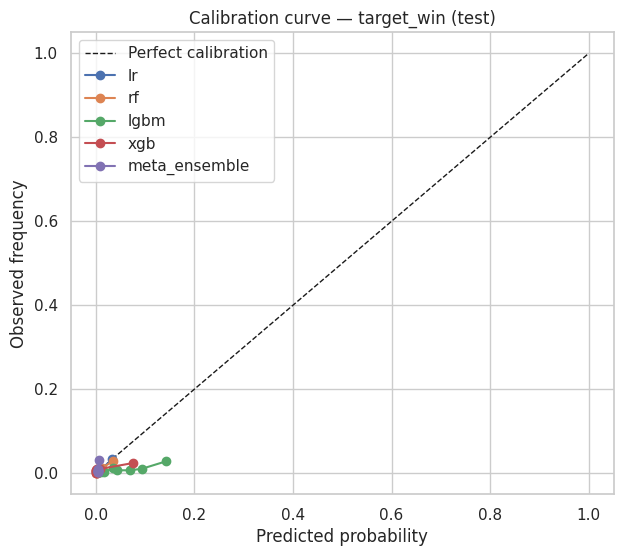

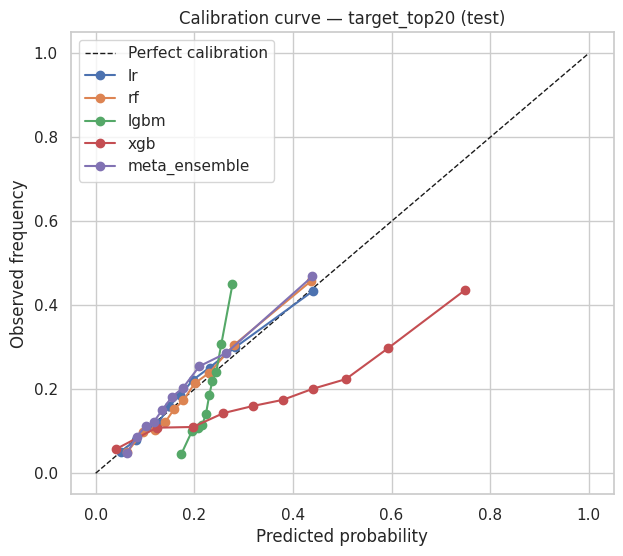

In [7]:
# Calibration curves for Win and Top20 on TEST split

def plot_calibration_for_target(target: str, split: str = "test", n_bins: int = 10):
    y = y_cls_test[target] if split == "test" else y_cls_valid[target]
    probs = all_probs[split][target]

    plt.figure(figsize=(7, 6))
    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    for model_name, p in probs.items():
        frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", label=model_name)

    plt.title(f"Calibration curve — {target} ({split})")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.legend()
    plt.show()

plot_calibration_for_target("target_win", split="test")
plot_calibration_for_target("target_top20", split="test")

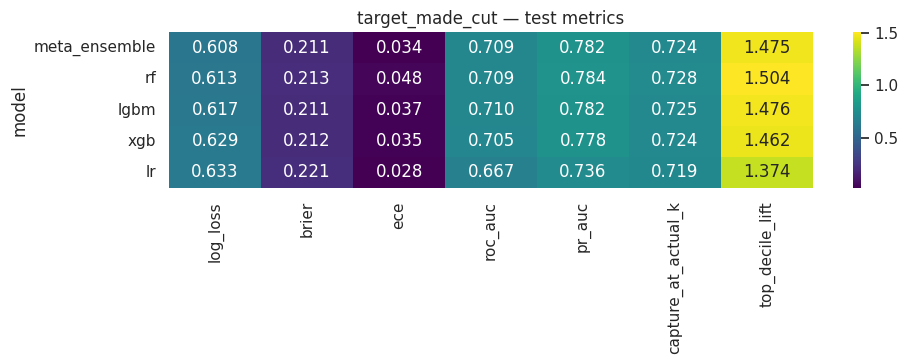

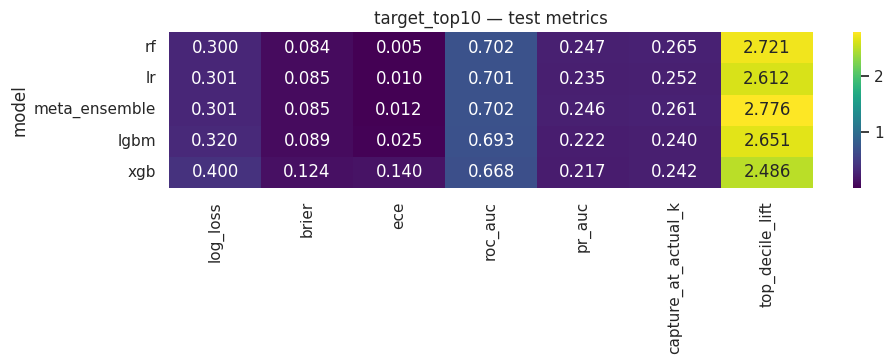

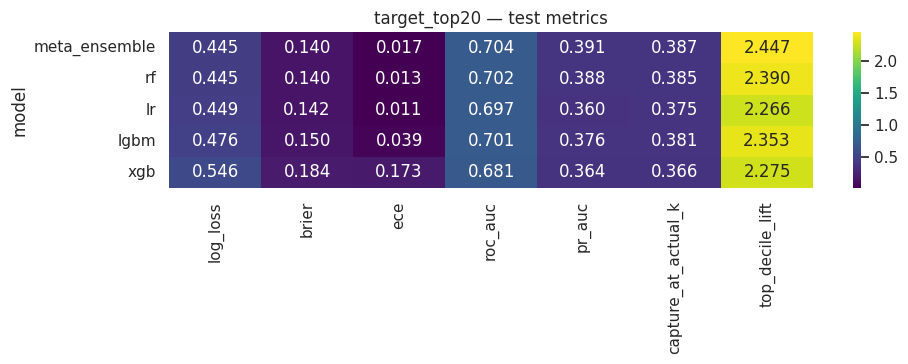

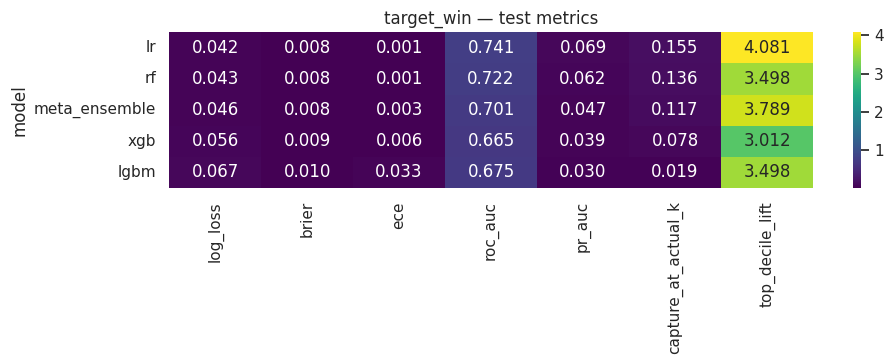

In [8]:
# Metric heatmaps (TEST)

for target in cls_targets:
    sub = cls_metrics[(cls_metrics["split"] == "test") & (cls_metrics["target"] == target)].copy()
    if sub.empty:
        continue
    heat = sub.set_index("model")[["log_loss", "brier", "ece", "roc_auc", "pr_auc", "capture_at_actual_k", "top_decile_lift"]]

    plt.figure(figsize=(10, 3.8))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"{target} — test metrics")
    plt.tight_layout()
    plt.show()

## Tournament-level backtest (hold-out)

Set `BACKTEST_SPLIT` to `"test"` or `"valid"`. Metrics are computed **per event** `(season, tournament)` then averaged.

**Win (`target_win`)**  
- **hit@K**: best rank (among tied winners) of any winner by model probability ≤ K.  
- **uniform_hit@K**: expected hit rate if you picked K players uniformly at random with **no replacement** and one winner: `K / n` (when `K ≤ n`).

**Top10 / Top20**  
- **recall@K**: fraction of actual positives that appear in the model’s top-K by probability.  
- **precision@K**: fraction of the model’s top-K that are positives.  
- **Uniform (random rank)** expectation: `E[|topK ∩ positives|] = K × (n_pos / n)`, so **uniform_recall@K ≈ K/n**, **uniform_precision@K ≈ n_pos/n**.

In [9]:
from IPython.display import display

# Hold-out split for event-level backtests
BACKTEST_SPLIT = "test"  # or "valid"

_split_df = test_df if BACKTEST_SPLIT == "test" else valid_df

WIN_KS = (1, 3, 5, 10, 20)
RANK_KS_TOP10 = (10, 15, 20, 30, 40)
RANK_KS_TOP20 = (20, 30, 40, 60)


def win_event_table(eval_df: pd.DataFrame, prob_col: str = "p", label_col: str = "y") -> pd.DataFrame:
    rows = []
    for (season, tournament), g in eval_df.groupby(["season", "tournament"], sort=False):
        n = int(len(g))
        if n == 0:
            continue
        pos = int(g[label_col].sum())
        if pos == 0:
            continue
        ranks = g[prob_col].rank(ascending=False, method="min")
        best_w = ranks[g[label_col] == 1].min()
        if pd.isna(best_w):
            continue
        best_w = int(best_w)
        row = {
            "season": season,
            "tournament": tournament,
            "field_size": n,
            "n_positive": pos,
            "winner_best_rank": best_w,
        }
        for k in WIN_KS:
            kk = min(int(k), n)
            row[f"hit@{k}"] = float(best_w <= kk)
            # uniform: one random K-subset contains the winner with prob kk/n (single winner); multi-winner lower bound uses same kk/n as reference
            row[f"uniform_hit@{k}"] = float(kk / n) if n > 0 else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_win_hits(evt: pd.DataFrame) -> pd.Series:
    out = {"n_events": len(evt)}
    for k in WIN_KS:
        c = f"hit@{k}"
        u = f"uniform_hit@{k}"
        if c in evt.columns:
            out[f"mean_{c}"] = evt[c].mean()
        if u in evt.columns:
            out[f"mean_{u}"] = evt[u].mean()
    return pd.Series(out)


def rank_event_metrics(
    eval_df: pd.DataFrame, ks: tuple, prob_col: str = "p", label_col: str = "y"
) -> pd.DataFrame:
    rows = []
    for (season, tournament), g in eval_df.groupby(["season", "tournament"], sort=False):
        n = int(len(g))
        if n == 0:
            continue
        n_pos = int(g[label_col].sum())
        if n_pos == 0:
            continue
        g = g.sort_values(prob_col, ascending=False)
        y_sorted = g[label_col].values
        row = {
            "season": season,
            "tournament": tournament,
            "field_size": n,
            "n_positive": n_pos,
            "uniform_precision": n_pos / n,
        }
        for k in ks:
            kk = min(int(k), n)
            top_y = y_sorted[:kk]
            inter = int(top_y.sum())
            row[f"recall@{k}"] = inter / n_pos
            row[f"precision@{k}"] = inter / kk
            row[f"uniform_recall@{k}"] = kk / n if n_pos > 0 else np.nan
            row[f"uniform_precision@{k}"] = n_pos / n
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_rank(evt: pd.DataFrame, ks: tuple) -> pd.Series:
    out = {"n_events": len(evt)}
    for k in ks:
        for prefix in ("recall", "precision", "uniform_recall", "uniform_precision"):
            c = f"{prefix}@{k}"
            if c in evt.columns:
                out[f"mean_{c}"] = evt[c].mean()
    return pd.Series(out)


# --- Run backtests for every model / target available on this split ---

backtest_win_rows = []
backtest_top10_rows = []
backtest_top20_rows = []

for model_name in all_probs[BACKTEST_SPLIT].get("target_win", {}):
    p = all_probs[BACKTEST_SPLIT]["target_win"][model_name]
    ed = _split_df.copy()
    ed["p"] = p
    ed["y"] = ed["target_win"].astype(int)
    evt = win_event_table(ed)
    summ = summarize_win_hits(evt)
    summ["model"] = model_name
    summ["target"] = "target_win"
    summ["split"] = BACKTEST_SPLIT
    summ["season"] = np.nan
    backtest_win_rows.append(summ)
    # by season
    for season, sub in evt.groupby("season"):
        s2 = summarize_win_hits(sub)
        s2["model"] = model_name
        s2["target"] = "target_win"
        s2["split"] = BACKTEST_SPLIT
        s2["season"] = season
        backtest_win_rows.append(s2)

win_backtest_summary = pd.DataFrame(backtest_win_rows)
# Separate overall (no season) vs by-season
win_overall = win_backtest_summary[win_backtest_summary["season"].isna()].drop(columns=["season"], errors="ignore")
win_by_season = win_backtest_summary[win_backtest_summary["season"].notna()]

print(f"=== Win backtest ({BACKTEST_SPLIT}) — overall ===")
if len(win_overall) == 0:
    print("(No win probabilities computed — run classification cell above.)")
else:
    display(win_overall.sort_values("mean_hit@1", ascending=False))

for tgt, ks in [("target_top10", RANK_KS_TOP10), ("target_top20", RANK_KS_TOP20)]:
    for model_name in all_probs[BACKTEST_SPLIT].get(tgt, {}):
        p = all_probs[BACKTEST_SPLIT][tgt][model_name]
        ed = _split_df.copy()
        ed["p"] = p
        ed["y"] = ed[tgt].astype(int)
        evt = rank_event_metrics(ed, ks)
        summ = summarize_rank(evt, ks)
        summ["model"] = model_name
        summ["target"] = tgt
        summ["split"] = BACKTEST_SPLIT
        summ["season"] = np.nan
        if tgt == "target_top10":
            backtest_top10_rows.append(summ)
        else:
            backtest_top20_rows.append(summ)
        for season, sub in evt.groupby("season"):
            s2 = summarize_rank(sub, ks)
            s2["model"] = model_name
            s2["target"] = tgt
            s2["split"] = BACKTEST_SPLIT
            s2["season"] = season
            (backtest_top10_rows if tgt == "target_top10" else backtest_top20_rows).append(s2)

top10_bt = pd.DataFrame(backtest_top10_rows)
top20_bt = pd.DataFrame(backtest_top20_rows)

print(f"\n=== Top10 recall/precision ({BACKTEST_SPLIT}) — overall ===")
_t10 = top10_bt[top10_bt["season"].isna()].drop(columns=["season"], errors="ignore")
if len(_t10) == 0 or "mean_recall@10" not in _t10.columns:
    print("(No top10 backtest rows.)")
else:
    display(_t10.sort_values("mean_recall@10", ascending=False))

print(f"\n=== Top20 recall/precision ({BACKTEST_SPLIT}) — overall ===")
_t20 = top20_bt[top20_bt["season"].isna()].drop(columns=["season"], errors="ignore")
if len(_t20) == 0 or "mean_recall@20" not in _t20.columns:
    print("(No top20 backtest rows.)")
else:
    display(_t20.sort_values("mean_recall@20", ascending=False))

=== Win backtest (test) — overall ===


,n_events,mean_hit@1,mean_uniform_hit@1,mean_hit@3,mean_uniform_hit@3,mean_hit@5,mean_uniform_hit@5,mean_hit@10,mean_uniform_hit@10,mean_hit@20,mean_uniform_hit@20,model,target,split
8,103.0,0.252427,0.010159,0.281553,0.030478,0.310680,0.050797,0.446602,0.101594,0.514563,0.203188,lgbm,target_win,test
0,103.0,0.155340,0.010159,0.203883,0.030478,0.252427,0.050797,0.398058,0.101594,0.495146,0.203188,lr,target_win,test
4,103.0,0.135922,0.010159,0.203883,0.030478,0.242718,0.050797,0.339806,0.101594,0.475728,0.203188,rf,target_win,test
16,103.0,0.116505,0.010159,0.203883,0.030478,0.262136,0.050797,0.359223,0.101594,0.475728,0.203188,meta_ensemble,target_win,test
12,103.0,0.077670,0.010159,0.174757,0.030478,0.233010,0.050797,0.281553,0.101594,0.417476,0.203188,xgb,target_win,test



=== Top10 recall/precision (test) — overall ===


,n_events,mean_recall@10,mean_precision@10,mean_uniform_recall@10,mean_uniform_precision@10,mean_recall@15,mean_precision@15,mean_uniform_recall@15,mean_uniform_precision@15,mean_recall@20,...,mean_precision@30,mean_uniform_recall@30,mean_uniform_precision@30,mean_recall@40,mean_precision@40,mean_uniform_recall@40,mean_uniform_precision@40,model,target,split
4,105.0,0.239712,0.271429,0.101756,0.118851,0.326954,0.248254,0.152634,0.118851,0.404302,...,0.208254,0.295743,0.118851,0.621318,0.185794,0.381626,0.118851,rf,target_top10,test
0,105.0,0.232753,0.264762,0.101756,0.118851,0.317787,0.241905,0.152634,0.118851,0.388920,...,0.200317,0.295743,0.118851,0.619464,0.185079,0.381626,0.118851,lr,target_top10,test
16,105.0,0.232141,0.265714,0.101756,0.118851,0.321643,0.246984,0.152634,0.118851,0.388860,...,0.204444,0.295743,0.118851,0.613057,0.183651,0.381626,0.118851,meta_ensemble,target_top10,test
12,105.0,0.216446,0.249524,0.101756,0.118851,0.286379,0.220952,0.152634,0.118851,0.371240,...,0.185397,0.295743,0.118851,0.571996,0.172698,0.381626,0.118851,xgb,target_top10,test
8,105.0,0.215413,0.245714,0.101756,0.118851,0.303288,0.229841,0.152634,0.118851,0.392253,...,0.200952,0.295743,0.118851,0.603045,0.180317,0.381626,0.118851,lgbm,target_top10,test



=== Top20 recall/precision (test) — overall ===


,n_events,mean_recall@20,mean_precision@20,mean_uniform_recall@20,mean_uniform_precision@20,mean_recall@30,mean_precision@30,mean_uniform_recall@30,mean_uniform_precision@30,mean_recall@40,mean_precision@40,mean_uniform_recall@40,mean_uniform_precision@40,mean_recall@60,mean_precision@60,mean_uniform_recall@60,mean_uniform_precision@60,model,target,split
16,105.0,0.355629,0.398095,0.203511,0.229318,0.471721,0.359683,0.295743,0.229318,0.574350,0.336984,0.381626,0.229318,0.729967,0.296807,0.549026,0.229318,meta_ensemble,target_top20,test
4,105.0,0.350991,0.392381,0.203511,0.229318,0.473045,0.360317,0.295743,0.229318,0.569360,0.333413,0.381626,0.229318,0.729119,0.296013,0.549026,0.229318,rf,target_top20,test
8,105.0,0.347418,0.388571,0.203511,0.229318,0.470776,0.359365,0.295743,0.229318,0.572507,0.335556,0.381626,0.229318,0.736526,0.298712,0.549026,0.229318,lgbm,target_top20,test
0,105.0,0.340506,0.380952,0.203511,0.229318,0.469219,0.357143,0.295743,0.229318,0.567004,0.331984,0.381626,0.229318,0.734822,0.298077,0.549026,0.229318,lr,target_top20,test
12,105.0,0.335372,0.376190,0.203511,0.229318,0.452333,0.345714,0.295743,0.229318,0.548022,0.322222,0.381626,0.229318,0.708001,0.288871,0.549026,0.229318,xgb,target_top20,test


### Plots: model vs uniform baselines

Win charts compare **mean hit@K** across tournaments to **mean uniform_hit@K** (random `K` players). Top10/Top20 charts compare **mean recall@K** to **mean uniform_recall@K** for the same `K`.

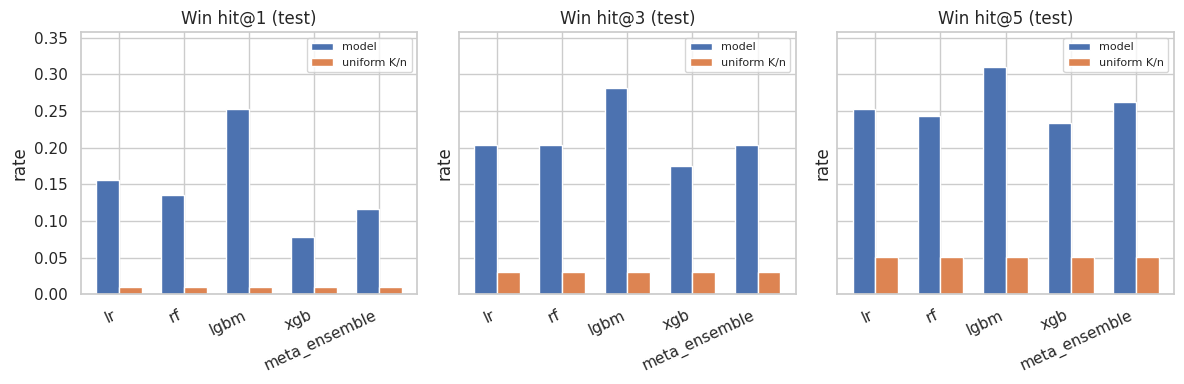

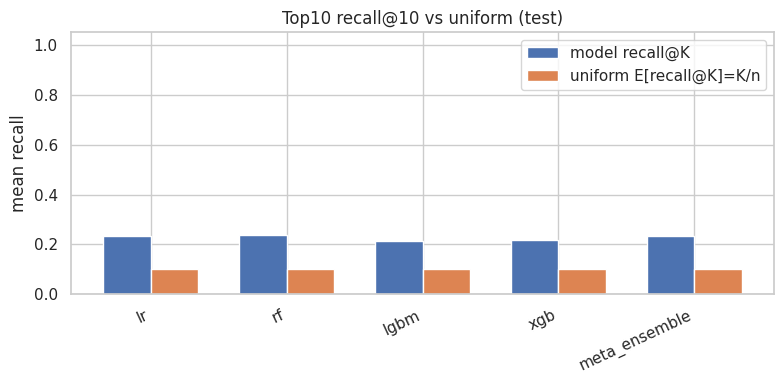

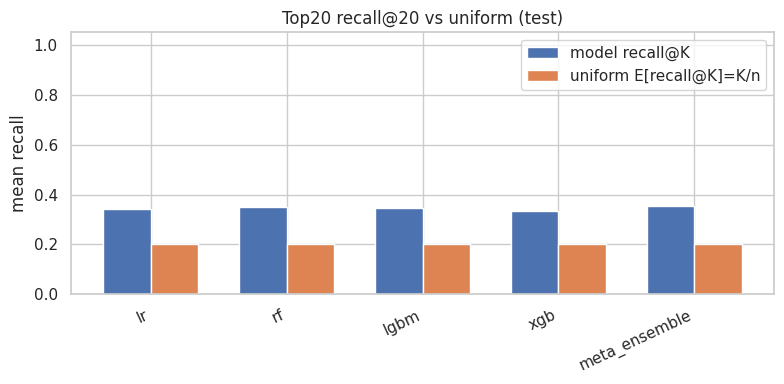


Win mean_hit@1 by season (test):


model,lgbm,lr,meta_ensemble,rf,xgb
season,,,,,
2024.0,0.234043,0.170213,0.042553,0.127660,0.021277
2025.0,0.304348,0.152174,0.195652,0.152174,0.130435
2026.0,0.100000,0.100000,0.100000,0.100000,0.100000


In [10]:
# Win: hit@K vs uniform (overall backtest)
if len(win_overall) > 0:
    plot_ks = (1, 3, 5)
    fig, axes = plt.subplots(1, len(plot_ks), figsize=(4 * len(plot_ks), 4), sharey=True)
    if len(plot_ks) == 1:
        axes = [axes]
    for ax, k in zip(axes, plot_ks):
        hc, uc = f"mean_hit@{k}", f"mean_uniform_hit@{k}"
        if hc not in win_overall.columns:
            ax.set_visible(False)
            continue
        sub = win_overall[["model", hc, uc]].dropna()
        x = np.arange(len(sub))
        w = 0.35
        ax.bar(x - w / 2, sub[hc], width=w, label="model")
        ax.bar(x + w / 2, sub[uc], width=w, label="uniform K/n")
        ax.set_xticks(x)
        ax.set_xticklabels(sub["model"], rotation=25, ha="right")
        ax.set_ylabel("rate")
        ax.set_title(f"Win hit@{k} ({BACKTEST_SPLIT})")
        ax.legend(loc="upper right", fontsize=8)
        ax.set_ylim(0, max(0.15, sub[[hc, uc]].max().max() * 1.15))
    plt.tight_layout()
    plt.show()
else:
    print("Skip win plots (no overall win backtest).")

# Top10 / Top20: recall@K vs uniform_recall@K
for bt, k_fixed, title in [
    (top10_bt, 10, "Top10"),
    (top20_bt, 20, "Top20"),
]:
    ovr = bt[bt["season"].isna()].drop(columns=["season"], errors="ignore")
    rc = f"mean_recall@{k_fixed}"
    urc = f"mean_uniform_recall@{k_fixed}"
    if len(ovr) == 0 or rc not in ovr.columns:
        print(f"Skip {title} recall plot.")
        continue
    sub = ovr[["model", rc, urc]].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(sub))
    w = 0.35
    ax.bar(x - w / 2, sub[rc], width=w, label="model recall@K")
    ax.bar(x + w / 2, sub[urc], width=w, label="uniform E[recall@K]=K/n")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model"], rotation=25, ha="right")
    ax.set_ylabel("mean recall")
    ax.set_title(f"{title} recall@{k_fixed} vs uniform ({BACKTEST_SPLIT})")
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

# By-season table: win hit@1 (wide)
if len(win_by_season) > 0 and "mean_hit@1" in win_by_season.columns:
    print(f"\nWin mean_hit@1 by season ({BACKTEST_SPLIT}):")
    wide = win_by_season.pivot(index="season", columns="model", values="mean_hit@1")
    display(wide.sort_index())
else:
    print("\n(No per-season win rows.)")

In [11]:
SLICE_SPLIT = BACKTEST_SPLIT  # 'test' or 'valid'
sl_df = (test_df if SLICE_SPLIT == "test" else valid_df).copy().reset_index(drop=True)

# Pacing feature: days since player's prior start (within split frame for diagnostics)
sl_df = sl_df.sort_values(["name", "start", "tournament"]).reset_index(drop=True)
sl_df["days_since_prev_start"] = (
    sl_df.groupby("name")["start"].diff().dt.days.astype(float)
)

# Robust bins
sl_df["liv_share_bin"] = pd.cut(
    sl_df["liv_share_last_20"].fillna(-0.01),
    bins=[-1.0, 0.05, 0.40, 1.0],
    labels=["low_liv", "mixed", "high_liv"],
)
sl_df["strength_share_bin"] = pd.cut(
    sl_df["strong_field_share_last_20"].fillna(-0.01),
    bins=[-1.0, 0.10, 0.50, 1.0],
    labels=["low_strong", "mixed", "high_strong"],
)
sl_df["pace_bin"] = pd.cut(
    sl_df["days_since_prev_start"].fillna(999),
    bins=[-1, 8, 20, 45, 9999],
    labels=["very_frequent", "normal", "sporadic", "very_sparse"],
)


def safe_auc(y, p):
    y = np.asarray(y)
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)


def sliced_cls_metrics(eval_df: pd.DataFrame, y: np.ndarray, p: np.ndarray, by_col: str) -> pd.DataFrame:
    tmp = eval_df[[by_col]].copy()
    tmp["y"] = y
    tmp["p"] = np.clip(p, 1e-7, 1 - 1e-7)
    tmp = tmp.dropna(subset=[by_col])

    rows = []
    for g, sub in tmp.groupby(by_col, sort=False):
        if len(sub) < 40:
            continue
        ys = sub["y"].values.astype(int)
        ps = sub["p"].values.astype(float)
        rows.append(
            {
                "slice": str(g),
                "n": len(sub),
                "base_rate": ys.mean(),
                "log_loss": log_loss(ys, ps, labels=[0, 1]),
                "brier": brier_score_loss(ys, ps),
                "auc": safe_auc(ys, ps),
            }
        )
    out = pd.DataFrame(rows)
    if not len(out):
        return out

    out["balanced_log_loss"] = out["log_loss"].mean()
    out["balanced_brier"] = out["brier"].mean()
    out["weighted_log_loss"] = np.average(out["log_loss"], weights=out["n"])
    out["weighted_brier"] = np.average(out["brier"], weights=out["n"])
    return out.sort_values("n", ascending=False)


slice_reports = {}
for target in ["target_win", "target_top10", "target_top20"]:
    y = (sl_df[target].astype(int).values if target in sl_df.columns else None)
    if y is None:
        continue
    slice_reports[target] = {}
    for model_name, probs in all_probs[SLICE_SPLIT].get(target, {}).items():
        if len(probs) != len(sl_df):
            # alignment guard (should match because all_probs built from same split frame)
            continue
        per_model = {}
        for dim in ["liv_share_bin", "strength_share_bin", "pace_bin"]:
            per_model[dim] = sliced_cls_metrics(sl_df, y, probs, dim)
        slice_reports[target][model_name] = per_model

# Show compact summary table: balanced vs weighted log loss by dimension
summary_rows = []
for target, model_map in slice_reports.items():
    for model_name, dim_map in model_map.items():
        for dim, tbl in dim_map.items():
            if len(tbl) == 0:
                continue
            summary_rows.append(
                {
                    "target": target,
                    "model": model_name,
                    "dimension": dim,
                    "n_slices": len(tbl),
                    "balanced_log_loss": float(tbl["balanced_log_loss"].iloc[0]),
                    "weighted_log_loss": float(tbl["weighted_log_loss"].iloc[0]),
                    "balanced_brier": float(tbl["balanced_brier"].iloc[0]),
                    "weighted_brier": float(tbl["weighted_brier"].iloc[0]),
                }
            )

slice_summary = pd.DataFrame(summary_rows)
print(f"Tour-aware slice summary ({SLICE_SPLIT})")
display(slice_summary.sort_values(["target", "dimension", "balanced_log_loss"]))

# Inspect one model/target deeply
INSPECT_TARGET = "target_win"
INSPECT_MODEL = "meta_ensemble" if "meta_ensemble" in all_probs[SLICE_SPLIT].get(INSPECT_TARGET, {}) else next(iter(all_probs[SLICE_SPLIT].get(INSPECT_TARGET, {})), None)

if INSPECT_MODEL is not None and INSPECT_TARGET in slice_reports and INSPECT_MODEL in slice_reports[INSPECT_TARGET]:
    print(f"\nDetailed slices — {INSPECT_TARGET} / {INSPECT_MODEL}")
    for dim in ["liv_share_bin", "strength_share_bin", "pace_bin"]:
        print(f"\n[{dim}]")
        display(slice_reports[INSPECT_TARGET][INSPECT_MODEL][dim])
else:
    print("No inspectable target/model available.")

Tour-aware slice summary (test)


,target,model,dimension,n_slices,balanced_log_loss,weighted_log_loss,balanced_brier,weighted_brier
18,target_top10,rf,liv_share_bin,1,0.299577,0.299577,0.084329,0.084329
15,target_top10,lr,liv_share_bin,1,0.300771,0.300771,0.084849,0.084849
27,target_top10,meta_ensemble,liv_share_bin,1,0.301129,0.301129,0.084570,0.084570
21,target_top10,lgbm,liv_share_bin,1,0.320257,0.320257,0.089015,0.089015
24,target_top10,xgb,liv_share_bin,1,0.400247,0.400247,0.123726,0.123726
20,target_top10,rf,pace_bin,4,0.282789,0.299577,0.078749,0.084329
17,target_top10,lr,pace_bin,4,0.283067,0.300771,0.079142,0.084849
29,target_top10,meta_ensemble,pace_bin,4,0.283600,0.301129,0.078852,0.084570
23,target_top10,lgbm,pace_bin,4,0.306793,0.320257,0.083926,0.089015
26,target_top10,xgb,pace_bin,4,0.378837,0.400247,0.116041,0.123726



Detailed slices — target_win / meta_ensemble

[liv_share_bin]


,slice,n,base_rate,log_loss,brier,auc,balanced_log_loss,balanced_brier,weighted_log_loss,weighted_brier
0,low_liv,12719,0.008098,0.046438,0.00802,0.700866,0.046438,0.00802,0.046438,0.00802



[strength_share_bin]


,slice,n,base_rate,log_loss,brier,auc,balanced_log_loss,balanced_brier,weighted_log_loss,weighted_brier
0,low_strong,7772,0.004117,0.026757,0.004101,0.581866,0.037141,0.006238,0.046438,0.00802
1,mixed,4808,0.014767,0.079445,0.014586,0.704112,0.037141,0.006238,0.046438,0.00802
2,high_strong,139,0.000000,0.005222,0.000027,NaN,0.037141,0.006238,0.046438,0.00802



[pace_bin]


,slice,n,base_rate,log_loss,brier,auc,balanced_log_loss,balanced_brier,weighted_log_loss,weighted_brier
2,very_frequent,5747,0.008874,0.050504,0.008787,0.680756,0.044942,0.007737,0.046438,0.00802
3,normal,2449,0.006942,0.040045,0.006869,0.732754,0.044942,0.007737,0.046438,0.00802
1,sporadic,2316,0.008636,0.049820,0.008562,0.653767,0.044942,0.007737,0.046438,0.00802
0,very_sparse,2207,0.006797,0.039397,0.006730,0.766469,0.044942,0.007737,0.046438,0.00802


In [12]:
# Iterative model selection board + Masters/majors diagnostics
from IPython.display import display
import re

ITER_SPLIT = BACKTEST_SPLIT if "BACKTEST_SPLIT" in globals() else "test"

# --- 1) Dual objective leaderboards (calibration vs ranking) ---
calibration_cols = ["log_loss", "brier", "ece"]

calib_best = (
    cls_metrics.sort_values(["target", "split", "log_loss"])
    .groupby(["target", "split"], as_index=False)
    .first()
)
calib_best = calib_best[calib_best["split"] == ITER_SPLIT].copy()

ranking_best_rows = []

# Win ranking uses event hit@K
if "win_overall" in globals() and len(win_overall):
    w = win_overall.copy()
    w["ranking_score"] = (
        0.55 * w["mean_hit@1"] + 0.25 * w["mean_hit@5"] + 0.20 * w["mean_hit@10"]
    )
    bw = w.sort_values("ranking_score", ascending=False).iloc[0]
    ranking_best_rows.append(
        {
            "target": "target_win",
            "split": ITER_SPLIT,
            "model": bw["model"],
            "ranking_score": bw["ranking_score"],
            "ranking_metric_1": bw["mean_hit@1"],
            "ranking_metric_2": bw["mean_hit@10"],
            "ranking_view": "hit@k",
        }
    )

# Top10 ranking uses recall/precision@10
if "_t10" in globals() and len(_t10):
    t10 = _t10.copy()
    t10["ranking_score"] = 0.75 * t10["mean_recall@10"] + 0.25 * t10["mean_precision@10"]
    b10 = t10.sort_values("ranking_score", ascending=False).iloc[0]
    ranking_best_rows.append(
        {
            "target": "target_top10",
            "split": ITER_SPLIT,
            "model": b10["model"],
            "ranking_score": b10["ranking_score"],
            "ranking_metric_1": b10["mean_recall@10"],
            "ranking_metric_2": b10["mean_precision@10"],
            "ranking_view": "recall/precision@10",
        }
    )

# Top20 ranking uses recall/precision@20
if "_t20" in globals() and len(_t20):
    t20 = _t20.copy()
    t20["ranking_score"] = 0.75 * t20["mean_recall@20"] + 0.25 * t20["mean_precision@20"]
    b20 = t20.sort_values("ranking_score", ascending=False).iloc[0]
    ranking_best_rows.append(
        {
            "target": "target_top20",
            "split": ITER_SPLIT,
            "model": b20["model"],
            "ranking_score": b20["ranking_score"],
            "ranking_metric_1": b20["mean_recall@20"],
            "ranking_metric_2": b20["mean_precision@20"],
            "ranking_view": "recall/precision@20",
        }
    )

ranking_best = pd.DataFrame(ranking_best_rows)

if len(calib_best):
    print(f"=== Calibration-first winners ({ITER_SPLIT}) ===")
    display(calib_best[["target", "model", "log_loss", "brier", "ece", "roc_auc", "pr_auc"]].sort_values("target"))

if len(ranking_best):
    print(f"\n=== Ranking-first winners ({ITER_SPLIT}) ===")
    display(ranking_best.sort_values("target"))

# Production recommendation split by use-case
reco_rows = []
for target in sorted(set(calib_best["target"]).union(set(ranking_best.get("target", [])))):
    cb = calib_best[calib_best["target"] == target]
    rb = ranking_best[ranking_best["target"] == target] if len(ranking_best) else pd.DataFrame()
    if len(cb):
        reco_rows.append({
            "target": target,
            "use_case": "calibration/pricing",
            "recommended_model": cb.iloc[0]["model"],
            "primary_metric": "log_loss",
            "metric_value": cb.iloc[0]["log_loss"],
        })
    if len(rb):
        reco_rows.append({
            "target": target,
            "use_case": "ranking/picks",
            "recommended_model": rb.iloc[0]["model"],
            "primary_metric": rb.iloc[0]["ranking_view"],
            "metric_value": rb.iloc[0]["ranking_score"],
        })

reco_df = pd.DataFrame(reco_rows)
print(f"\n=== Recommended deployment by objective ({ITER_SPLIT}) ===")
display(reco_df.sort_values(["target", "use_case"]))


# --- 2) Event-level majors diagnostics (Masters + recent major trends) ---

def major_label(tournament: str) -> str:
    t = str(tournament).lower()
    if "masters" in t:
        return "masters"
    if "pga championship" in t:
        return "pga_championship"
    if ("u.s. open" in t) or re.search(r"\bus open\b", t):
        return "us_open"
    if "open championship" in t or "british open" in t:
        return "open_championship"
    return "non_major"


def event_binary_log_loss(y: np.ndarray, p: np.ndarray) -> float:
    y = np.asarray(y).astype(int)
    p = np.clip(np.asarray(p).astype(float), 1e-7, 1 - 1e-7)
    if len(y) < 2:
        return np.nan
    return float(log_loss(y, p, labels=[0, 1]))


def event_auc(y: np.ndarray, p: np.ndarray) -> float:
    y = np.asarray(y).astype(int)
    if len(np.unique(y)) < 2:
        return np.nan
    return float(roc_auc_score(y, p))


diag_split_df = (test_df if ITER_SPLIT == "test" else valid_df).copy().reset_index(drop=True)
diag_split_df["major_type"] = diag_split_df["tournament"].map(major_label)
diag_split_df["is_major"] = (diag_split_df["major_type"] != "non_major").astype(int)

# Use ranking model if available, else calibration winner
model_choice = {}
for target in ["target_win", "target_top10", "target_top20", "target_made_cut"]:
    rb = ranking_best[ranking_best["target"] == target] if len(ranking_best) else pd.DataFrame()
    cb = calib_best[calib_best["target"] == target]
    if len(rb):
        model_choice[target] = rb.iloc[0]["model"]
    elif len(cb):
        model_choice[target] = cb.iloc[0]["model"]

major_event_rows = []
for target, model_name in model_choice.items():
    if model_name not in all_probs[ITER_SPLIT].get(target, {}):
        continue

    p = np.asarray(all_probs[ITER_SPLIT][target][model_name])
    if len(p) != len(diag_split_df):
        continue

    work = diag_split_df[["season", "tournament", "major_type", "is_major", "liv_share_last_20", "strong_field_share_last_20", target]].copy()
    work["p"] = np.clip(p, 1e-7, 1 - 1e-7)
    work["y"] = work[target].astype(int)

    for (season, tournament, major_type), g in work.groupby(["season", "tournament", "major_type"], sort=False):
        row = {
            "target": target,
            "model": model_name,
            "season": int(season),
            "tournament": tournament,
            "major_type": major_type,
            "is_major": int(major_type != "non_major"),
            "n_players": len(g),
            "base_rate": float(g["y"].mean()),
            "event_log_loss": event_binary_log_loss(g["y"].values, g["p"].values),
            "event_auc": event_auc(g["y"].values, g["p"].values),
            "mean_liv_share_last_20": float(g["liv_share_last_20"].fillna(0).mean()),
            "mean_strong_field_share_last_20": float(g["strong_field_share_last_20"].fillna(0).mean()),
        }

        if target == "target_win" and g["y"].sum() > 0:
            ranks = g["p"].rank(ascending=False, method="min")
            best_winner_rank = ranks[g["y"] == 1].min()
            row["winner_best_rank"] = float(best_winner_rank) if pd.notna(best_winner_rank) else np.nan

        major_event_rows.append(row)

major_event_df = pd.DataFrame(major_event_rows)

if len(major_event_df):
    major_rollup = (
        major_event_df.groupby(["target", "model", "is_major"], as_index=False)
        .agg(
            n_events=("tournament", "nunique"),
            mean_event_log_loss=("event_log_loss", "mean"),
            mean_event_auc=("event_auc", "mean"),
            mean_base_rate=("base_rate", "mean"),
            mean_liv_share_last_20=("mean_liv_share_last_20", "mean"),
            mean_strong_field_share_last_20=("mean_strong_field_share_last_20", "mean"),
            mean_winner_best_rank=("winner_best_rank", "mean"),
        )
    )

    print(f"\n=== Major vs non-major performance ({ITER_SPLIT}) ===")
    display(major_rollup.sort_values(["target", "is_major"]))

    masters_df = major_event_df[major_event_df["major_type"] == "masters"].copy()
    if len(masters_df):
        print(f"\n=== Masters event diagnostics ({ITER_SPLIT}) ===")
        display(
            masters_df[
                [
                    "season", "target", "model", "tournament", "event_log_loss", "event_auc",
                    "base_rate", "mean_liv_share_last_20", "mean_strong_field_share_last_20", "winner_best_rank"
                ]
            ].sort_values(["season", "target"])
        )

    major_season_trend = (
        major_event_df[major_event_df["is_major"] == 1]
        .groupby(["season", "target", "model"], as_index=False)
        .agg(
            n_events=("tournament", "nunique"),
            mean_event_log_loss=("event_log_loss", "mean"),
            mean_event_auc=("event_auc", "mean"),
            mean_liv_share_last_20=("mean_liv_share_last_20", "mean"),
            mean_strong_field_share_last_20=("mean_strong_field_share_last_20", "mean"),
            mean_winner_best_rank=("winner_best_rank", "mean"),
        )
    )

    print(f"\n=== Major trend by season (selected model per target, {ITER_SPLIT}) ===")
    display(major_season_trend.sort_values(["target", "season"]))

else:
    print("No event-level major diagnostics generated (likely missing probabilities or split mismatch).")


# --- 3) Practical iterative loop guidance with concrete thresholds ---
print("\n=== Iterative gating rules (apply every retrain) ===")
print("1) calibration/pricing gate: no target can worsen test log_loss by > 1.5% vs prior champion")
print("2) ranking gate: win hit@1 and top10 recall@10 must each improve by >= 2% relative or stay flat with better calibration")
print("3) majors robustness gate: major mean_event_log_loss cannot degrade by > 2.5% even if non-major improves")
print("4) shift monitor: if major mean_liv_share_last_20 or mean_strong_field_share_last_20 shifts > 20% YoY, retrain with recency weighting")


=== Calibration-first winners (test) ===


,target,model,log_loss,brier,ece,roc_auc,pr_auc
0,target_made_cut,meta_ensemble,0.607785,0.210672,0.033513,0.709030,0.781699
2,target_top10,rf,0.299577,0.084329,0.004939,0.702408,0.247102
4,target_top20,meta_ensemble,0.444596,0.140006,0.016743,0.703660,0.390632
6,target_win,lr,0.042281,0.007765,0.000552,0.740914,0.068953



=== Ranking-first winners (test) ===


,target,split,model,ranking_score,ranking_metric_1,ranking_metric_2,ranking_view
1,target_top10,test,rf,0.247641,0.239712,0.271429,recall/precision@10
2,target_top20,test,meta_ensemble,0.366246,0.355629,0.398095,recall/precision@20
0,target_win,test,lgbm,0.305825,0.252427,0.446602,hit@k



=== Recommended deployment by objective (test) ===


...


=== Masters event diagnostics (test) ===


,season,target,model,tournament,event_log_loss,event_auc,base_rate,mean_liv_share_last_20,mean_strong_field_share_last_20,winner_best_rank
402,2024,target_made_cut,meta_ensemble,Masters Tournament,0.870917,0.671264,0.674157,0.0,0.212413,NaN
192,2024,target_top10,rf,Masters Tournament,0.304686,0.882284,0.123596,0.0,0.212413,NaN
297,2024,target_top20,meta_ensemble,Masters Tournament,0.506942,0.696078,0.235955,0.0,0.212413,NaN
87,2024,target_win,lgbm,Masters Tournament,0.085108,0.943182,0.011236,0.0,0.212413,1.0
383,2025,target_made_cut,meta_ensemble,Masters Tournament,0.916593,0.706649,0.557895,0.0,0.215819,NaN
173,2025,target_top10,rf,Masters Tournament,0.295909,0.844156,0.115789,0.0,0.215819,NaN
278,2025,target_top20,meta_ensemble,Masters Tournament,0.462767,0.708667,0.210526,0.0,0.215819,NaN
68,2025,target_win,lgbm,Masters Tournament,0.088720,0.946809,0.010526,0.0,0.215819,1.0



=== Major trend by season (selected model per target, test) ===


,season,target,model,n_events,mean_event_log_loss,mean_event_auc,mean_liv_share_last_20,mean_strong_field_share_last_20,mean_winner_best_rank
0,2024,target_made_cut,meta_ensemble,3,0.703583,0.717139,0.0,0.183235,NaN
4,2025,target_made_cut,meta_ensemble,3,0.749562,0.701477,0.0,0.182141,NaN
1,2024,target_top10,rf,3,0.247198,0.855014,0.0,0.183235,NaN
5,2025,target_top10,rf,3,0.272215,0.793433,0.0,0.182141,NaN
2,2024,target_top20,meta_ensemble,3,0.388921,0.782774,0.0,0.183235,NaN
6,2025,target_top20,meta_ensemble,3,0.417743,0.716423,0.0,0.182141,NaN
3,2024,target_win,lgbm,3,0.067849,0.941276,0.0,0.183235,3.666667
7,2025,target_win,lgbm,3,0.078395,0.681194,0.0,0.182141,45.666667



=== Iterative gating rules (apply every retrain) ===
1) calibration/pricing gate: no target can worsen test log_loss by > 1.5% vs prior champion
2) ranking gate: win hit@1 and top10 recall@10 must each improve by >= 2% relative or stay flat with better calibration
3) majors robustness gate: major mean_event_log_loss cannot degrade by > 2.5% even if non-major improves
4) shift monitor: if major mean_liv_share_last_20 or mean_strong_field_share_last_20 shifts > 20% YoY, retrain with recency weighting


In [ ]:
# Cross-tour evaluation diagnostics: per-model metrics by LIV share bins
# Groups test-set players by liv_share_last_20 and reports RMSE/MAE for
# regression and log_loss/AUC for classification per bin.

from sklearn.metrics import mean_squared_error, mean_absolute_error, log_loss, roc_auc_score

CROSS_TOUR_SPLIT = "test"
ct_df = (test_df if CROSS_TOUR_SPLIT == "test" else valid_df).copy().reset_index(drop=True)

ct_df["liv_share_bin"] = pd.cut(
    ct_df["liv_share_last_20"].fillna(0),
    bins=[-0.01, 0.001, 0.15, 0.40, 1.01],
    labels=["PGA-only (0)", "Low LIV (0-15%)", "Mid LIV (15-40%)", "High LIV (40%+)"],
)

# Build regression pred dict for the chosen split
_reg_preds = reg_test_preds if CROSS_TOUR_SPLIT == "test" else reg_valid_preds

# --- Regression by LIV share ---
reg_crosstour_rows = []
for model_name in ["ridge", "rf", "lgbm", "xgb", "nn", "meta"]:
    if model_name not in _reg_preds:
        continue
    preds = np.asarray(_reg_preds[model_name])
    if len(preds) != len(ct_df):
        continue
    ct_df["_sg_pred"] = preds
    for bin_label, g in ct_df.groupby("liv_share_bin", observed=True):
        valid_mask = g["target_sg_per_round"].notna()
        gy = g.loc[valid_mask, "target_sg_per_round"].values
        gp = g.loc[valid_mask, "_sg_pred"].values
        if len(gy) < 10:
            continue
        display_name = "meta_ensemble" if model_name == "meta" else model_name
        reg_crosstour_rows.append({
            "model": display_name,
            "liv_share_bin": str(bin_label),
            "n": len(gy),
            "rmse": float(np.sqrt(mean_squared_error(gy, gp))),
            "mae": float(mean_absolute_error(gy, gp)),
        })
ct_df.drop(columns=["_sg_pred"], errors="ignore", inplace=True)

reg_ct_df = pd.DataFrame(reg_crosstour_rows)
if len(reg_ct_df):
    print(f"=== Regression (SG/R) by LIV share bin ({CROSS_TOUR_SPLIT}) ===")
    display(reg_ct_df.pivot_table(
        index="model", columns="liv_share_bin",
        values=["rmse", "mae"], aggfunc="first"
    ).round(4))

# --- Classification by LIV share ---
cls_crosstour_rows = []
for target in cls_targets:
    for model_name, probs_arr in all_probs.get(CROSS_TOUR_SPLIT, {}).get(target, {}).items():
        p = np.asarray(probs_arr)
        if len(p) != len(ct_df):
            continue
        ct_df["_cls_pred"] = np.clip(p, 1e-7, 1 - 1e-7)
        for bin_label, g in ct_df.groupby("liv_share_bin", observed=True):
            if len(g) < 10:
                continue
            valid_mask = g[target].notna()
            gy = g.loc[valid_mask, target].astype(int).values
            gp = g.loc[valid_mask, "_cls_pred"].values
            if len(gy) < 10 or len(np.unique(gy)) < 2:
                continue
            cls_crosstour_rows.append({
                "target": target,
                "model": model_name,
                "liv_share_bin": str(bin_label),
                "n": len(gy),
                "log_loss": float(log_loss(gy, gp, labels=[0, 1])),
                "auc": float(roc_auc_score(gy, gp)),
            })
        ct_df.drop(columns=["_cls_pred"], errors="ignore", inplace=True)

cls_ct_df = pd.DataFrame(cls_crosstour_rows)
if len(cls_ct_df):
    for target in cls_targets:
        sub = cls_ct_df[cls_ct_df["target"] == target]
        if sub.empty:
            continue
        print(f"\n=== {target} by LIV share bin ({CROSS_TOUR_SPLIT}) ===")
        display(sub.pivot_table(
            index="model", columns="liv_share_bin",
            values=["log_loss", "auc"], aggfunc="first"
        ).round(4))

# --- LIV player backtest: predicted vs actual for key players ---
LIV_KEY_PLAYERS = ["Jon Rahm", "Bryson DeChambeau", "Patrick Reed", "Joaquin Niemann", "Tyrrell Hatton"]
liv_backtest_df = ct_df[ct_df["name"].isin(LIV_KEY_PLAYERS)].copy()
if len(liv_backtest_df) > 0:
    print(f"\n=== LIV key player backtest ({CROSS_TOUR_SPLIT}, {len(liv_backtest_df)} rows) ===")
    if "meta" in _reg_preds:
        meta_preds_full = np.asarray(_reg_preds["meta"])
        if len(meta_preds_full) == len(ct_df):
            liv_backtest_df["pred_sg_round"] = meta_preds_full[liv_backtest_df.index]
            display(
                liv_backtest_df[["name", "season", "tournament", "target_sg_per_round",
                                 "pred_sg_round", "position_num", "liv_share_last_20"]]
                .sort_values(["name", "season"])
                .head(40)
            )
            per_player = (
                liv_backtest_df.groupby("name", as_index=False)
                .agg(
                    n=("target_sg_per_round", "count"),
                    actual_mean_sg=("target_sg_per_round", "mean"),
                    pred_mean_sg=("pred_sg_round", "mean"),
                    mean_finish=("position_num", "mean"),
                )
            )
            per_player["error"] = per_player["pred_mean_sg"] - per_player["actual_mean_sg"]
            print("\nPer-player summary:")
            display(per_player.round(3))
else:
    print(f"\nNo LIV key player rows found in {CROSS_TOUR_SPLIT} split.")

print("\n=== Cross-tour evaluation complete ===")